# 🎬 TMDB Movie Data — Exploratory Data Analysis
**Dataset:** 4800+ movies from The Movie Database (TMDB)  
**Goal:** Explore patterns in genres, budgets, revenues, ratings and directors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  # to parse JSON-like columns

# Makes your plots look nice
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Loading & Merging the Data
We load two CSV files — one with movie details and one with cast/crew — 
and merge them into a single dataframe.

**Note:**
Download the TMDB dataset and place the CSV files inside a `datasets/` folder before running the notebook.

In [2]:
# Load both files
movies = pd.read_csv("datasets/tmdb_5000_movies.csv")
credits = pd.read_csv("datasets/tmdb_5000_credits.csv")

# Check the shape (rows, columns)
print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)

# Preview first 5 rows
movies.head()

Movies shape: (4803, 20)
Credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
# Column names and data types
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [4]:
print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)
print("\nMovies columns:\n", movies.columns.tolist())
print("\nCredits columns:\n", credits.columns.tolist())

Movies shape: (4803, 20)
Credits shape: (4803, 4)

Movies columns:
 ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credits columns:
 ['movie_id', 'title', 'cast', 'crew']


In [5]:
# Basic statistics (mean, min, max etc.)
movies.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


# Missing Value Handling

This section checks and handles missing or inconsistent values
to ensure accurate analysis.

In [6]:
print("Missing values in Movies:")
print(movies.isnull().sum())

Missing values in Movies:
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64


### Observation
Some columns contain missing values.
Relevant columns were cleaned or converted appropriately before analysis.

In [7]:
# Rename 'id' in movies to match 'movie_id' in credits
movies = movies.rename(columns={'id': 'movie_id'})

# Merge both dataframes
df = movies.merge(credits, on='movie_id')

print("Merged shape:", df.shape)
df.head()

Merged shape: (4803, 23)


,budget,genres,homepage,movie_id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## 2. Data Cleaning
The genres, cast and crew columns are stored as JSON strings. 
We parse them into proper Python lists for analysis.

In [8]:
def parse_list_column(text):
    """Converts a JSON-like string into a list of names"""
    try:
        items = ast.literal_eval(text)  # converts string → actual list
        return [item['name'] for item in items]
    except:
        return []

In [9]:
df['genres']               = df['genres'].apply(parse_list_column)
df['keywords']             = df['keywords'].apply(parse_list_column)
df['production_companies'] = df['production_companies'].apply(parse_list_column)
df['spoken_languages']     = df['spoken_languages'].apply(parse_list_column)

In [10]:
def parse_cast(text):
    try:
        items = ast.literal_eval(text)
        return [item['name'] for item in items[:3]]  # only top 3
    except:
        return []

df['cast'] = df['cast'].apply(parse_cast)

In [11]:
def get_director(text):
    try:
        items = ast.literal_eval(text)
        for item in items:
            if item['job'] == 'Director':
                return item['name']
    except:
        pass
    return None

df['director'] = df['crew'].apply(get_director)

In [12]:
print(df.columns.tolist())

['budget', 'genres', 'homepage', 'movie_id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average', 'vote_count', 'title_y', 'cast', 'crew', 'director']


In [13]:
# Drop duplicate title and rename title_x → title
df = df.drop(columns=['title_y'])
df = df.rename(columns={'title_x': 'title'})

# Verify it worked
df[['title', 'genres', 'cast', 'director']].head()

,title,genres,cast,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski
2,Spectre,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan
4,John Carter,"[Action, Adventure, Science Fiction]","[Taylor Kitsch, Lynn Collins, Samantha Morton]",Andrew Stanton


## 3. Exploratory Analysis
We answer 6 key questions about the dataset using charts.

## Question 1: What are the most common genres?
**Why this matters:** Understanding which genres dominate helps us see 
what kind of movies get made the most.

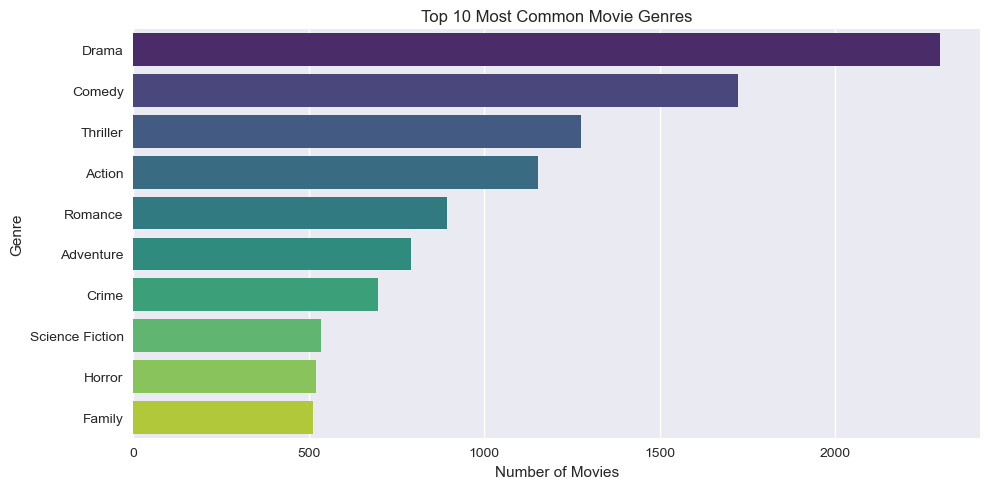

In [14]:
from collections import Counter

# Flatten all genres into one big list
all_genres = sum(df['genres'].dropna(), [])

# Count each genre
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=genre_df, x='Count', y='Genre', 
            hue='Genre', palette='viridis', legend=False)
plt.title('Top 10 Most Common Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**Insight:** Drama and Comedy are the most produced genres, 
suggesting studios play it safe with familiar audience favorites.

## Question 2: Do higher budget movies earn more revenue?
**Why this matters:** We want to see if spending more money 
actually guarantees higher returns.

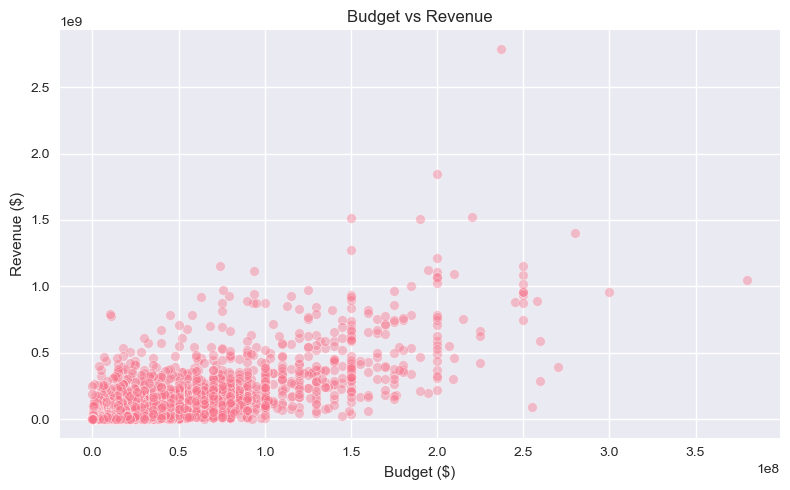

In [15]:
# Filter out movies with 0 budget or revenue (missing data)
budget_df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=budget_df, x='budget', y='revenue', alpha=0.4)
plt.title('Budget vs Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

**Insight:** There is a general positive correlation — higher budget 
movies tend to earn more. However, many high-budget films still 
underperform, meaning budget alone doesn't guarantee success.

## Question 3: How are movie ratings distributed?
**Why this matters:** This tells us whether most movies are 
generally good, bad, or average.

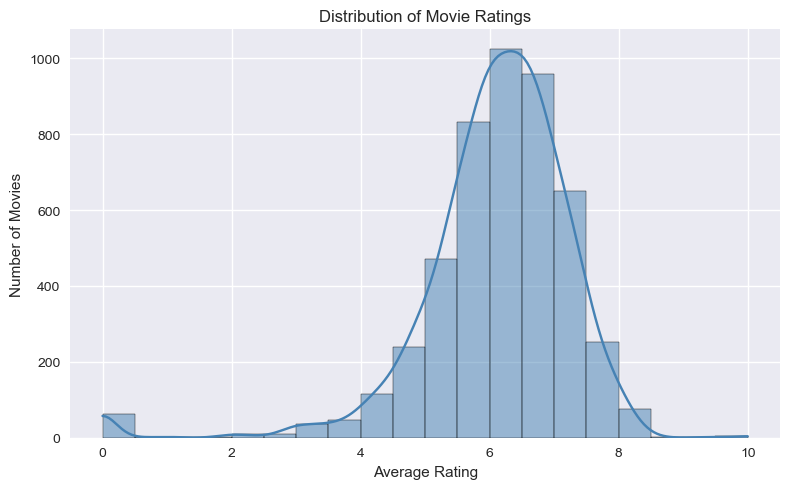

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['vote_average'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

**Insight:** Ratings follow a roughly normal distribution centered 
around 6-7, meaning most movies are considered average to good. 
Very few movies score below 4 or above 8.

## Question 4: Which movies earned the highest revenue?
**Why this matters:** Identifying blockbusters helps us understand 
what the commercial peak of the film industry looks like.

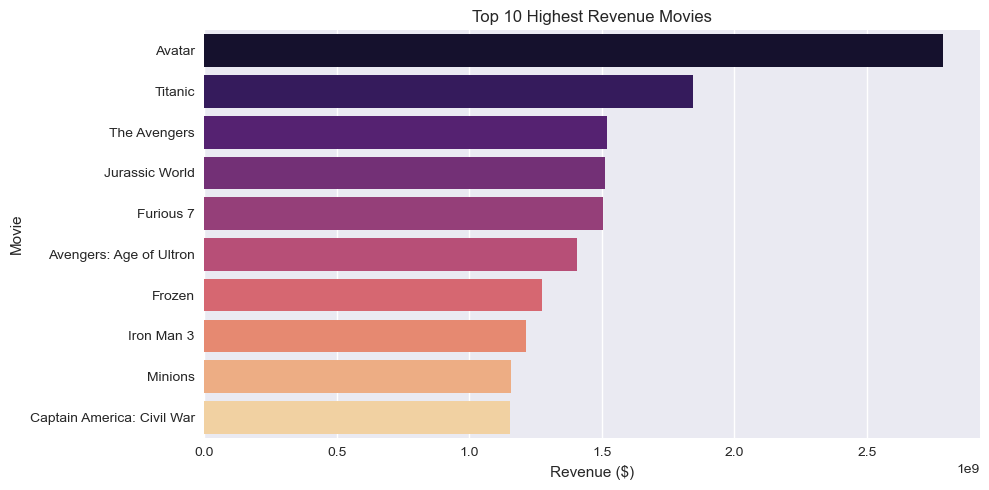

In [17]:
# Sort by revenue and take top 10
top_revenue = df[df['revenue'] > 0].nlargest(10, 'revenue')[['title', 'revenue']]

plt.figure(figsize=(10, 5))
sns.barplot(data=top_revenue, x='revenue', y='title',
            hue='title', palette='magma', legend=False)
plt.title('Top 10 Highest Revenue Movies')
plt.xlabel('Revenue ($)')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()

**Insight:** Avatar leads by a significant margin, followed by 
franchise movies like Star Wars and Avengers — suggesting that 
sequels and sci-fi dominate box office records.

## Question 5: Which directors have made the most movies?
**Why this matters:** Prolific directors often shape the style 
and trends of an entire era of cinema.

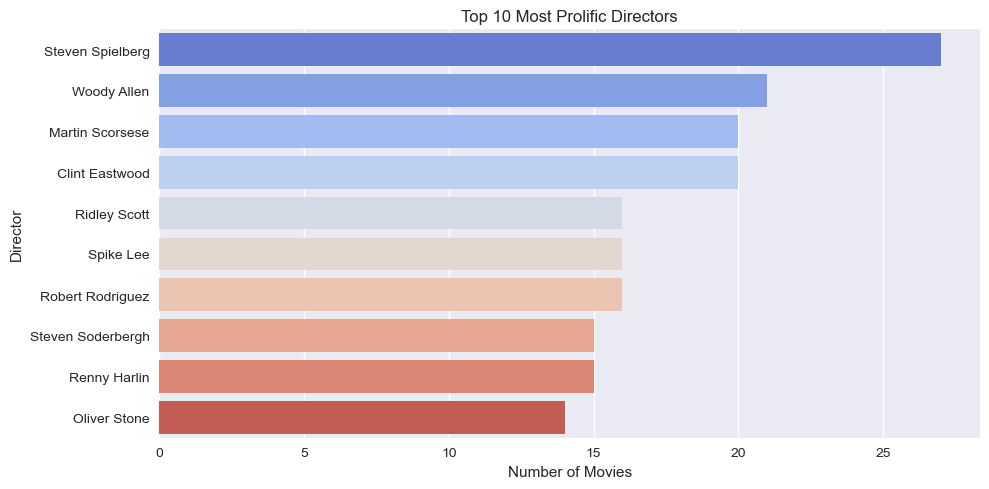

In [18]:
# Count movies per director
top_directors = df['director'].value_counts().head(10).reset_index()
top_directors.columns = ['Director', 'Movie Count']

plt.figure(figsize=(10, 5))
sns.barplot(data=top_directors, x='Movie Count', y='Director',
            hue='Director', palette='coolwarm', legend=False)
plt.title('Top 10 Most Prolific Directors')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

**Insight:** Directors like Steven Spielberg and Woody Allen appear 
most frequently, reflecting long and consistent careers spanning decades.

## Question 6: How have movie releases changed over the years?
**Why this matters:** This shows us how the film industry has 
grown over time.

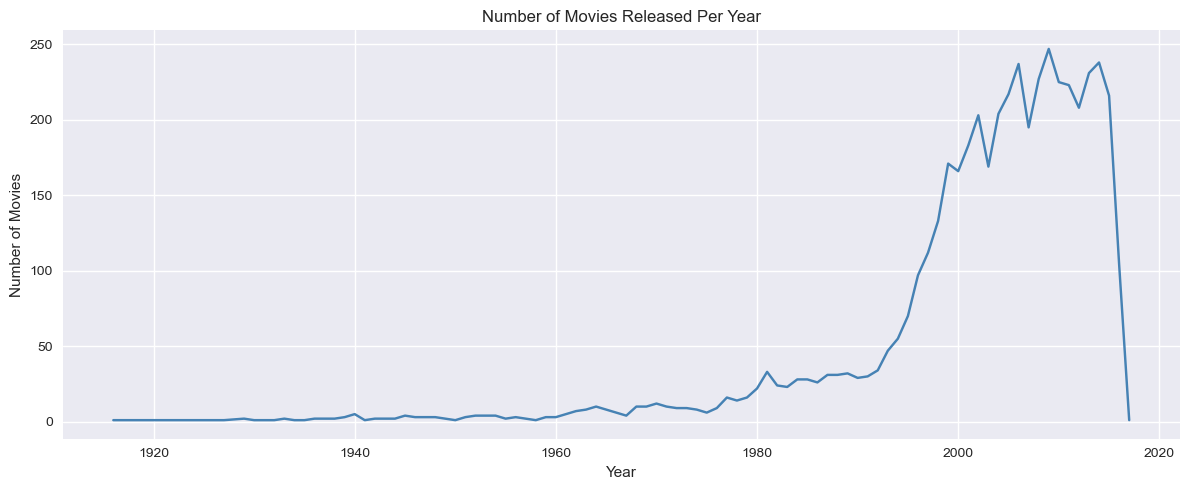

In [19]:
# Extract year from release_date
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Count movies per year
movies_per_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values, color='steelblue')
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

**Insight:** Movie production has increased dramatically since the 
1990s, with a sharp rise in the 2000s — reflecting growth in 
global cinema and streaming demand.

# Correlation Analysis

This heatmap shows the correlation between important numerical movie features.
Correlation values range from -1 to 1.

- Positive values → variables increase together
- Negative values → one increases while the other decreases
- Values close to 0 → weak relationship

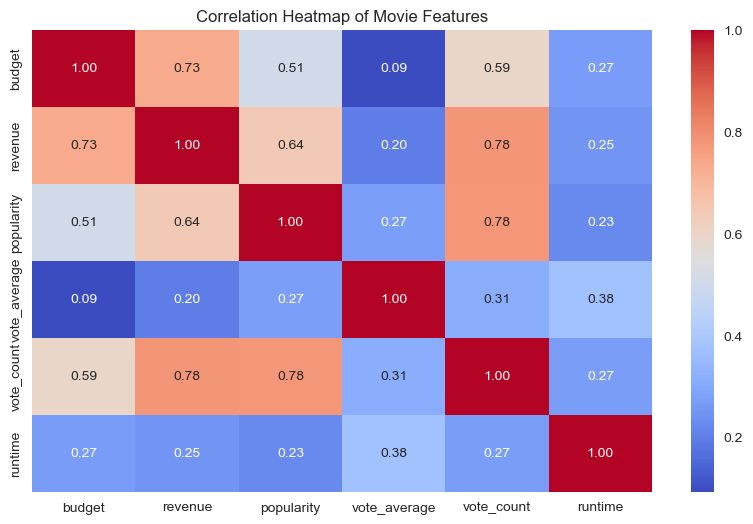

In [20]:
# Select important numerical columns
corr_columns = [
    'budget',
    'revenue',
    'popularity',
    'vote_average',
    'vote_count',
    'runtime'
]

# Create correlation matrix
corr_matrix = df[corr_columns].corr()

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Movie Features")
plt.show()

### Observation

- Budget and revenue show a strong positive correlation.
- Popular movies tend to receive more votes.
- Vote average has weaker correlation with revenue.
- Runtime has relatively low correlation with other features.

# Extension Questions

## Extension 1: Which actors appear most frequently?
**Why this matters:** Frequently cast actors dominate the industry 
and are often associated with box office success.

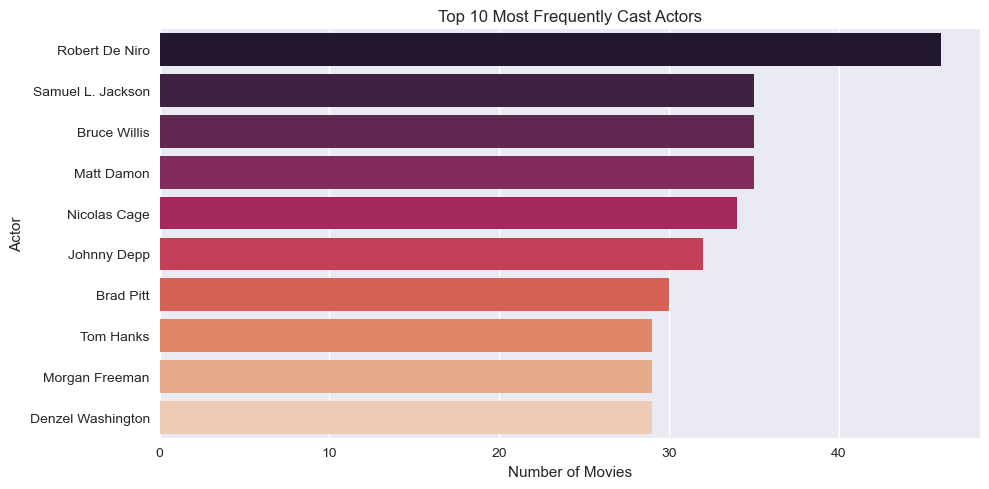

In [21]:
# Flatten all cast lists into one big list
all_actors = sum(df['cast'].dropna(), [])

# Count appearances
actor_counts = Counter(all_actors)
actor_df = pd.DataFrame(actor_counts.most_common(10), columns=['Actor', 'Appearances'])

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=actor_df, x='Appearances', y='Actor',
            hue='Actor', palette='rocket', legend=False)
plt.title('Top 10 Most Frequently Cast Actors')
plt.xlabel('Number of Movies')
plt.ylabel('Actor')
plt.tight_layout()
plt.show()

**Insight:** These actors consistently appear across multiple movies, 
reflecting their star power and commercial reliability for studios.

## Extension 2: Which month is best for releasing a movie?
**Why this matters:** Release timing is a key strategy for studios. 
Certain months like summer and holidays are known for blockbusters — 
let's verify this with data.

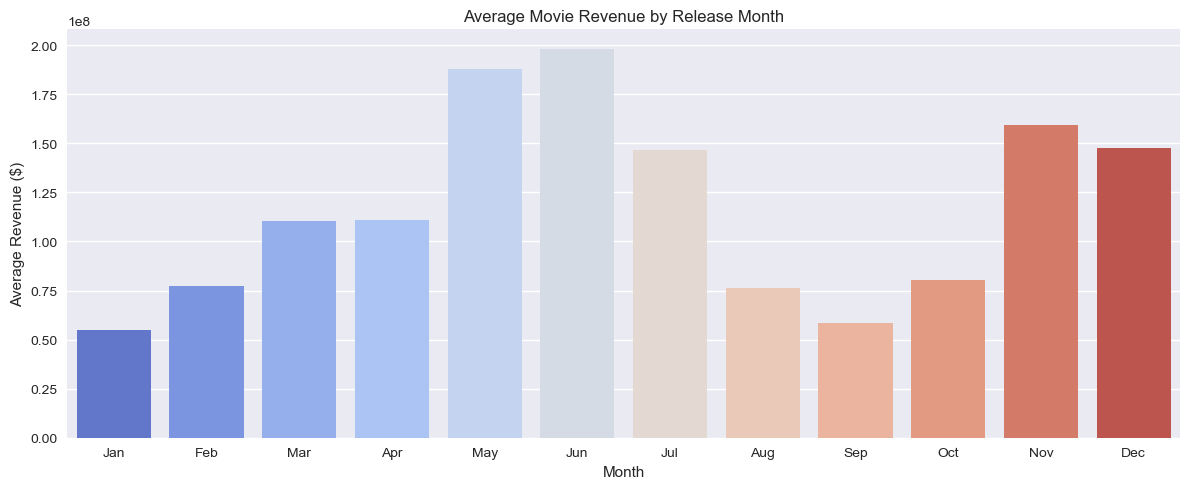

In [22]:
# Extract month from release_date
df['release_month'] = pd.to_datetime(df['release_date'], errors='coerce').dt.month

# Map month numbers to names
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['release_month'] = df['release_month'].map(month_names)

# Calculate average revenue per month
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_revenue = (df[df['revenue'] > 0]
                   .groupby('release_month')['revenue']
                   .mean()
                   .reindex(month_order)
                   .reset_index())
monthly_revenue.columns = ['Month', 'Avg Revenue']

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_revenue, x='Month', y='Avg Revenue',
            hue='Month', palette='coolwarm', legend=False)
plt.title('Average Movie Revenue by Release Month')
plt.xlabel('Month')
plt.ylabel('Average Revenue ($)')
plt.tight_layout()
plt.show()

**Insight:** Movies released in June and May tend to earn the 
highest average revenue — aligning with summer holidays. This confirms that studios 
deliberately time their biggest releases around these periods.

## Conclusion

In this project I explored 4800+ movies from the TMDB dataset. Key takeaways:

- **Drama and Comedy** are the most produced genres
- **Budget and revenue** are positively correlated but budget alone doesn't guarantee success
- **Most movies** are rated between 6 and 7 out of 10
- **Avatar** is the highest grossing movie in this dataset
- **Movie production** has grown significantly since the 1990s
- **Robert De Niro** consistently dominate the industry across multiple movies
- **June and May** are the best months to release a movie for maximum revenue

### What I learned
- How to load, clean and merge real-world datasets using pandas
- How to parse JSON-like columns using ast
- How to create and interpret visualizations using matplotlib and seaborn
- How to extract meaningful insights from raw data

### Next Steps
- Build a genre-based movie recommender
- Analyze which actor and director combinations earn the most revenue
- Investigate how ratings have changed over the decades